# ✈️ Airline Flight Data Analysis

**Müəllif:** Hüseyn Əliyev   
**Dataset:** airlines_flights_data.csv  
**Məqsəd:** Uçuş məlumatlarının ətraflı analizi

---

## 📋 Proyekt Strukturu

### Hissə 1: Datasetin Yoxlanması
- Data yükləmə
- İlk baxış
- Statistika

### Hissə 2: Vizuallaşdırma və Əlaqələr
-  1-7: Aviaşirkət, vaxt, marşrut analizi

### Hissə 3: Qiymət və Sinif Analizi
-  8-14: Sinif, müddət, durak, final analiz

---

## **HİSSƏ 1: DATASETİN YOXLANMASI VƏ ƏSAS STATİSTİKASI**

In [10]:
# Dataseti yükləmə
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Lazımı kitabxanalar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/airlines_flights_data.csv')
df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


Hər sətir bir uçuşu təmsil edir.

In [13]:
df.describe()

,index,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


Datasetdə 300,153 uçuş qeydi var.

Qiymət (Price)- Orta qiymət 20,890-dir, lakin biletlərin yarısı 7,425 vahiddən ucuzdur. Bu, bir neçə çox bahalı biletin ortalamanı yuxarı çəkdiyini göstərir.

Uçuş Müddəti (Duration)- Orta hesabla 12.2 saat çəkir. Ən qısa uçuş ~50 dəqiqə, ən uzunu isə ~50 saatdır.

Vaxt (Days_left)- Uçuşa orta hesabla 26 gün qalmış biletlər alınır.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


Cədvəldə 300,153 sətir və 12 sütun var.

Heç bir sütunda boş dəyər yoxdur (bütün sütunlar 300153 non-null).

8 sütun mətn (object), 4 sütun isə rəqəmsal (int64/float64) formatdadır.

In [15]:
# Boş dəyər yoxlaması
null_counts = df.isnull().sum()
print(null_counts)

if null_counts.sum() == 0:
    print("Heç bir boş dəyər yoxdur, data təmizdir!")
else:
    print(f"Cəmi {null_counts.sum()} boş dəyər var")

index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64
Heç bir boş dəyər yoxdur, data təmizdir!


In [16]:
# Əsas statistika

print("Dataset Əsas Statistika")


summary = pd.DataFrame({
    'Məlumat': [
        'Cəmi uçuş sayı',
        'Aviaşirkət sayı',
        'Mənbə şəhər sayı',
        'Təyinat şəhər sayı',
        'Ortalama qiymət',
        'Minimum qiymət',
        'Maksimum qiymət',
        'Ortalama uçuş müddəti',
        'Economy uçuş sayı',
        'Business uçuş sayı'
    ],
    'Dəyər': [
        df.shape[0],
        df['airline'].nunique(),
        df['source_city'].nunique(),
        df['destination_city'].nunique(),
        f"{df['price'].mean():.2f} AZN",
        f"{df['price'].min()} AZN",
        f"{df['price'].max()} AZN",
        f"{df['duration'].mean():.2f} saat",
        df[df['class'] == 'Economy'].shape[0],
        df[df['class'] == 'Business'].shape[0]
    ]
})

print(summary.to_string(index=False))

Dataset Əsas Statistika
              Məlumat        Dəyər
       Cəmi uçuş sayı       300153
      Aviaşirkət sayı            6
     Mənbə şəhər sayı            6
   Təyinat şəhər sayı            6
      Ortalama qiymət 20889.66 AZN
       Minimum qiymət     1105 AZN
      Maksimum qiymət   123071 AZN
Ortalama uçuş müddəti   12.22 saat
    Economy uçuş sayı       206666
   Business uçuş sayı        93487


## **HİSSƏ 2: VİZUALLAŞDIRMA VƏ ƏLAQƏLƏR**

In [17]:
# Datasetdə hansı aviaşirkətlər var və onların tezlikləri nə qədərdir?

airline_count = df['airline'].value_counts()

print(airline_count)

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64


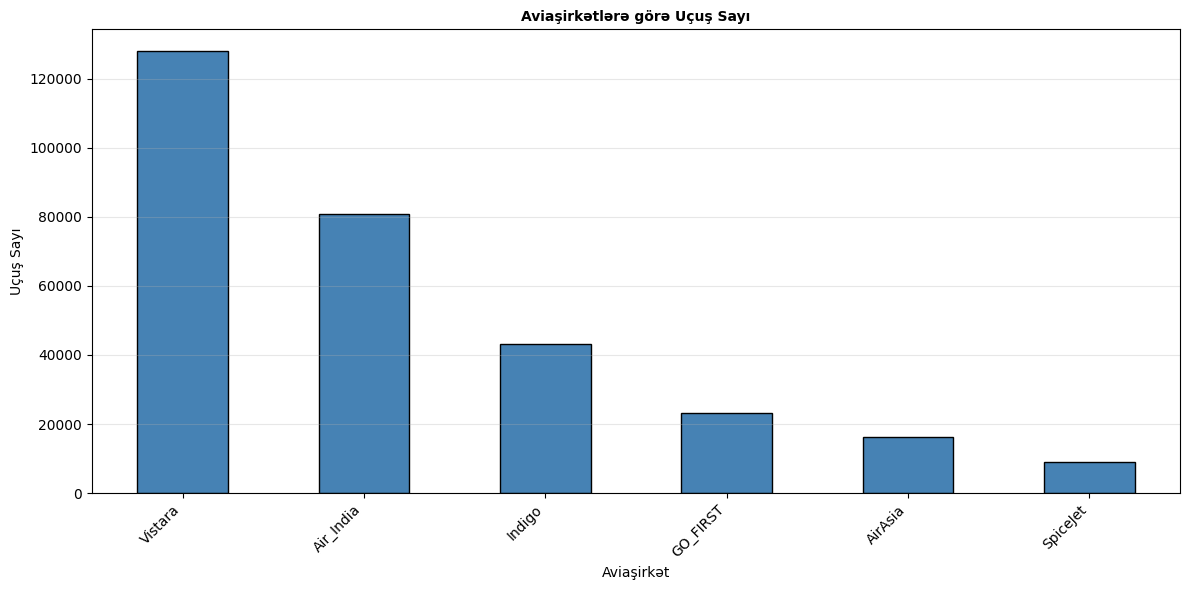

In [18]:
# Bar chart
plt.figure(figsize=(12, 6))
airline_count.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Aviaşirkətlərə görə Uçuş Sayı', fontsize=10, fontweight='bold')
plt.xlabel('Aviaşirkət', fontsize=10)
plt.ylabel('Uçuş Sayı', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### **Aviaşirkətlər və Tezlikləri Analiz**

**Nəticə:**
- Datasetdə 6 aviaşirkət var
- Ən çox uçuş: Vistara 127859 uçuş
- Ən az uçuş: SpiceJet 9011 uçuş


**Müşahidə:**
İki Nəhəngin Dominantlığı nəzərə çarpır : Vistara və Air_India birlikdə 200 mindən çox uçuş həyata keçirir. Bu o deməkdir ki, datadakı uçuşların təxminən 70%-i cəmi bu iki şirkətin payına düşür.

In [19]:
# Gediş vaxtı və Gəliş vaxtını təmsil edən Bar Qrafikləri

departure = df['departure_time'].value_counts()
arrival = df['arrival_time'].value_counts()

print("\nGEDİŞ VAXTLARI:")
print(departure)

print("\nGƏLİŞ VAXTLARI:")
print(arrival)


GEDİŞ VAXTLARI:
departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

GƏLİŞ VAXTLARI:
arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64


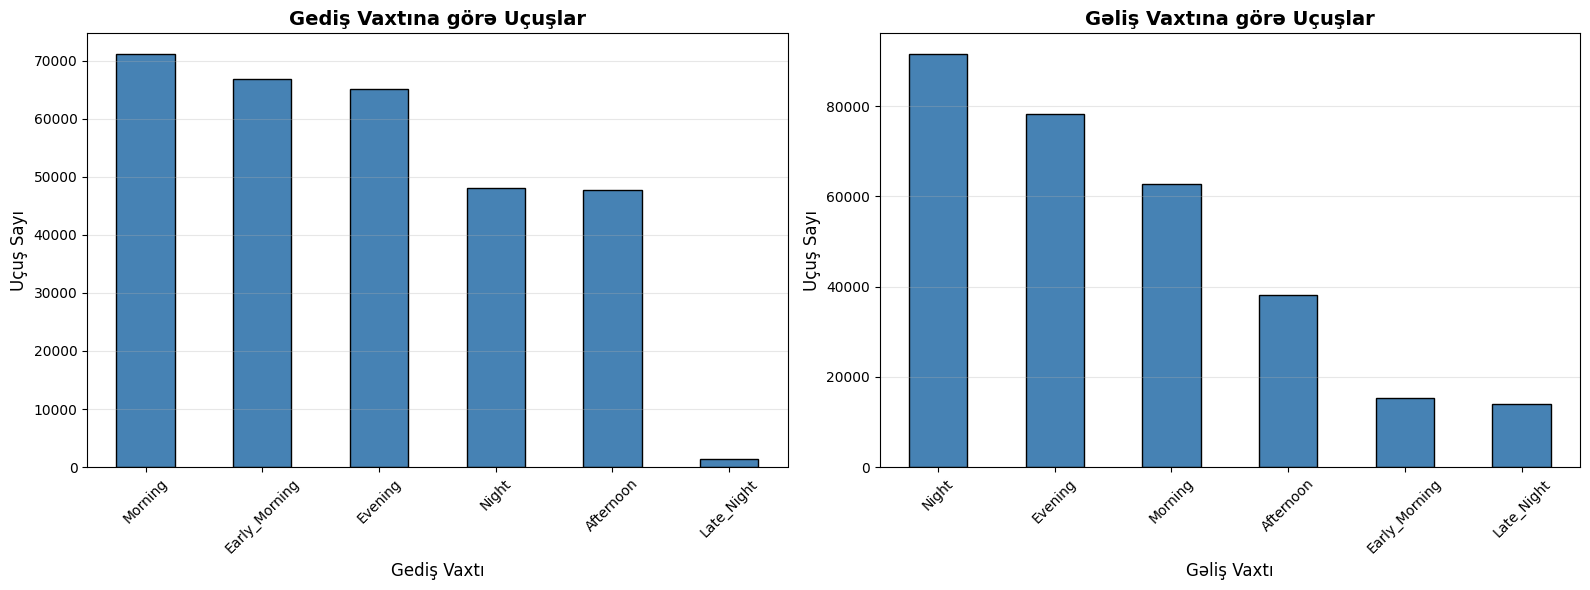

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gediş vaxtı
departure.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Gediş Vaxtına görə Uçuşlar', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gediş Vaxtı', fontsize=12)
axes[0].set_ylabel('Uçuş Sayı', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Gəliş vaxtı
arrival.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Gəliş Vaxtına görə Uçuşlar', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gəliş Vaxtı', fontsize=12)
axes[1].set_ylabel('Uçuş Sayı', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### **Gediş və Gəliş Vaxtları**

Gediş vaxtı:

Ən çox uçuş: Morning (71,146 uçuş)
Ən az uçuş: Late_Night (1,306 uçuş)


Gəliş vaxtı:

Ən çox gəliş: Night (91,538 uçuş)
Ən az gəliş: Late_Night (14,001 uçuş)


Müşahidə:

Səhər (Morning) və Erkən Səhər (Early_Morning) vaxtları gediş üçün ən populyar vaxtlardır.

Gəliş vaxtlarına baxdıqda isə təyyarələrin əksəriyyətinin Axşam (Evening) və Gecə (Night) saatlarında təyinat məntəqəsinə çatdığı görünür.

Həm gediş, həm də gəliş üçün Gecə Yarısı (Late_Night) ən az istifadə olunan vaxt kəsiyidir.

In [21]:
# Mənbə və Təyinat Şəhərlərini təmsil edən Bar Qrafikləri

# Mənbə və təyinat şəhərləri
source_counts = df['source_city'].value_counts()
destination_counts = df['destination_city'].value_counts()

print("\nMƏNBƏ ŞƏHƏRLƏRİ:")
print(source_counts)

print("\nTƏYİNAT ŞƏHƏRLƏRİ:")
print(destination_counts)


MƏNBƏ ŞƏHƏRLƏRİ:
source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

TƏYİNAT ŞƏHƏRLƏRİ:
destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64


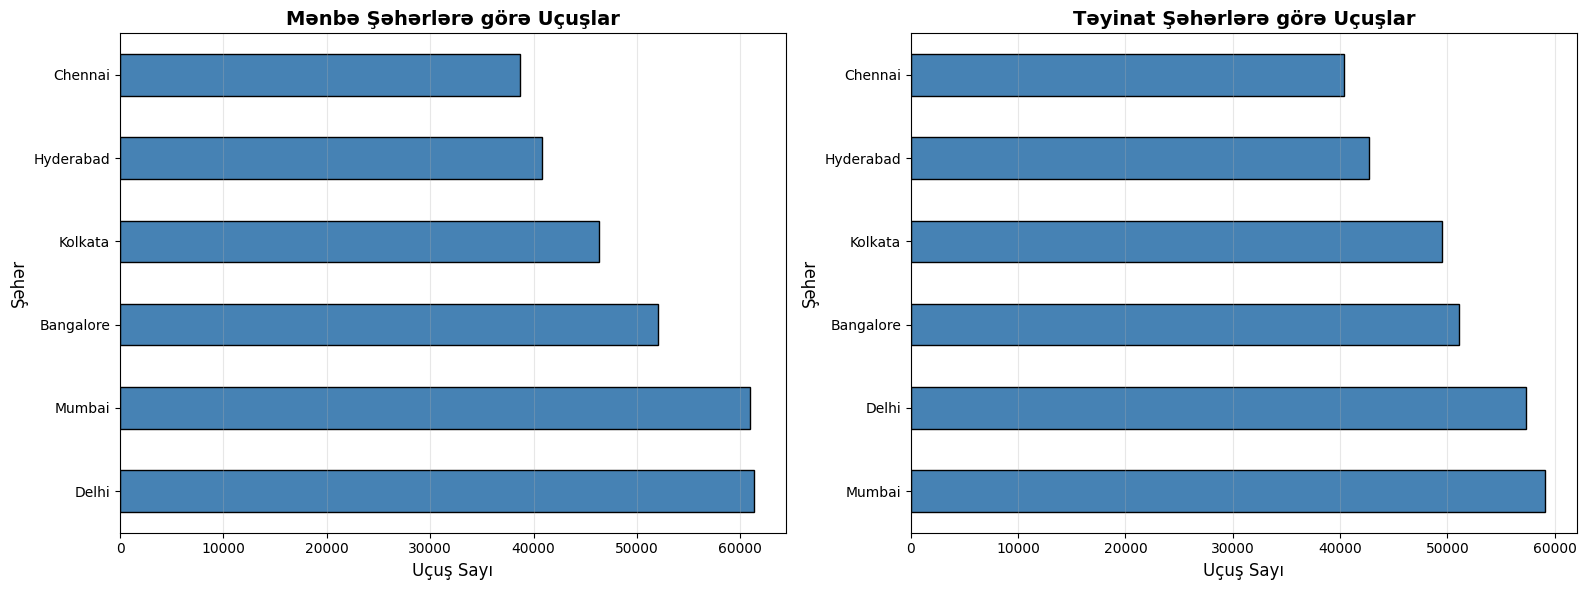

In [22]:
# İki qrafik yan-yana (horizontal bar)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mənbə şəhərlər
source_counts.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Mənbə Şəhərlərə görə Uçuşlar', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Uçuş Sayı', fontsize=12)
axes[0].set_ylabel('Şəhər', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# Təyinat şəhərlər
destination_counts.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Təyinat Şəhərlərə görə Uçuşlar', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Uçuş Sayı', fontsize=12)
axes[1].set_ylabel('Şəhər', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### **Mənbə və Təyinat Şəhərləri**

Mənbə şəhərlər (Source Cities):

Ən çox uçuş: Delhi (61,343 uçuş)
Ən az uçuş: Chennai (38,700 uçuş)

Təyinat şəhərlər (Destination Cities):

Ən populyar: Mumbai (59,097 uçuş)
Ən az: Chennai (40,368 uçuş)

Müşahidə:
Delhi və Mumbai həm mənbə, həm də təyinat şəhəri olaraq ən çox istifadə olunan, yəni datasetdəki ən aktiv hava nəqliyyatı mərkəzləridir. Chennai isə hər iki kateqoriya üzrə ən aşağı göstəriciyə malikdir.

In [23]:
# Qiymət aviaşirkətlərə görə dəyişirmi?

# Aviaşirkətlərə görə qiymət

print("QİYMƏT AVİAŞİRKƏTLƏRƏ GÖRƏ")
print("=" * 60)

airline_prices = df.groupby('airline')['price'].agg(['mean', 'median', 'min', 'max', 'std']).round(2)
airline_prices = airline_prices.sort_values('mean', ascending=False)
print(airline_prices)

QİYMƏT AVİAŞİRKƏTLƏRƏ GÖRƏ
               mean   median   min     max       std
airline                                             
Vistara    30396.54  15543.0  1714  123071  25637.16
Air_India  23507.02  11520.0  1526   90970  20905.12
SpiceJet    6179.28   5654.0  1106   34158   2999.63
GO_FIRST    5652.01   5336.0  1105   32803   2513.87
Indigo      5324.22   4453.0  1105   31952   3268.89
AirAsia     4091.07   3276.0  1105   31917   2824.06


### **Qiymət Aviaşirkətlərə görə**
Nəticələr:

Qiymət aviaşirkətlərə görə ciddi şəkildə dəyişir.

Ən bahalı: Vistara (ortalama 30,396.54 AZN)

Ən ucuz: AirAsia (ortalama 4,091.07 AZN)

Fərq: 26,305.47 AZN (Ən bahalı və ən ucuz ortalama arasındakı fərq)

Müşahidə:

Qiymət seqmentləri: Vistara və Air_India "premium" seqmentə aiddir (ortalamalar 20k+). SpiceJet, GO_FIRST, Indigo və AirAsia isə daha çox büdcə dostu (low-cost) şirkətlərdir (ortalamalar 4k - 6k arası).

Standart Yayılma (std): Vistara (25,637.16) və Air_India (20,905.12) üçün standart yayılma çox böyükdür. Bu, həmin şirkətlərdə qiymətlərin çox geniş diapazonda dəyişkən olduğunu, digər şirkətlərdə (məsələn, AirAsia - 2,824.06) isə qiymətlərin daha sabit və bir-birinə yaxın olduğunu göstərir.

In [24]:
# Bilet qiyməti gediş vaxtı və gəliş vaxtına əsasən dəyişirmi?

print("QİYMƏT GEDİŞ VƏ GƏLİŞ VAXTINA GÖRƏ")
print("=" * 60)

print("\nGEDİŞ VAXTINA GÖRƏ:")
dep_price_stats = df.groupby('departure_time')['price'].agg(['mean', 'median', 'min', 'max']).round(2)
dep_price_stats = dep_price_stats.sort_values('mean', ascending=False)
print(dep_price_stats)

print("\nGƏLİŞ VAXTINA GÖRƏ:")
arr_price_stats = df.groupby('arrival_time')['price'].agg(['mean', 'median', 'min', 'max']).round(2)
arr_price_stats = arr_price_stats.sort_values('mean', ascending=False)
print(arr_price_stats)

QİYMƏT GEDİŞ VƏ GƏLİŞ VAXTINA GÖRƏ

GEDİŞ VAXTINA GÖRƏ:
                    mean  median   min     max
departure_time                                
Night           23062.15  7813.0  1105  115211
Morning         21630.76  8112.0  1105  123071
Evening         21232.36  7425.0  1105  116562
Early_Morning   20370.68  7212.0  1105  117307
Afternoon       18179.20  6663.0  1105  111437
Late_Night       9295.30  4499.0  2050   56058

GƏLİŞ VAXTINA GÖRƏ:
                   mean  median   min     max
arrival_time                                 
Evening        23044.37  8854.0  1105  117307
Morning        22231.08  7687.0  1105  111964
Night          21586.76  7584.0  1105  123071
Afternoon      18494.60  6714.0  1105  115211
Early_Morning  14993.14  5800.0  1105  106416
Late_Night     11284.91  4867.0  1105   89257


### **Qiymət Gediş və Gəliş Vaxtına görə**

Gediş vaxtına görə:

Ən bahalı: Night (ortalama 23,062.15 AZN)

Ən ucuz: Late_Night (ortalama 9,295.30 AZN)


Gəliş vaxtına görə:

Ən bahalı: Evening (ortalama 23,044.37 AZN)

Ən ucuz: Late_Night (ortalama 11,284.91 AZN)

Müşahidə:

Gecə (Night) gedişləri və Axşam (Evening) gəlişləri ən bahalı vaxt kəsikləridir.

Gecə yarısı (Late_Night) həm gediş, həm də gəliş üçün hər zaman ən ucuz seçimdir.

Səbəb: Tələb və rahatlıq faktoru burada əsas rol oynayır. İnsanlar adətən gecə yarısı səfərə çıxmağı və ya mənzil başına çatmağı narahatlıq hesab etdikləri üçün bu biletlər daha ucuz təklif olunur. Günorta və axşam saatları isə iş və turizm baxımından daha əlverişli olduğu üçün qiymətlər yüksəlir.

In [25]:
# Qiymət mənbə və təyinatın dəyişməsi ilə necə dəyişir?

# Mənbə və təyinat kombinasiyasına görə qiymət
print("QİYMƏT MARŞRUTA GÖRƏ")
print("=" * 80)

# Marşrut yaradaq (Mənbə → Təyinat)
df['route'] = df['source_city'] + ' - ' + df['destination_city']

route_prices = df.groupby('route')['price'].agg(['mean', 'count']).round(1)
route_prices.columns = ['Ortalama_Qiymət', 'Uçuş_Sayı']
route_prices = route_prices.sort_values('Ortalama_Qiymət', ascending=False)

print("\nTop 10 Ən BAHALI marşrut:")
print(route_prices.head(10))

print("\nTop 10 Ən UCUZ marşrut:")
print(route_prices.tail(10))

QİYMƏT MARŞRUTA GÖRƏ

Top 10 Ən BAHALI marşrut:
                     Ortalama_Qiymət  Uçuş_Sayı
route                                          
Chennai - Bangalore          25081.9       6493
Kolkata - Chennai            23660.4       6653
Bangalore - Kolkata          23500.1      10028
Bangalore - Chennai          23321.9       6410
Mumbai - Bangalore           23147.9      12885
Bangalore - Mumbai           23128.6      12939
Mumbai - Chennai             22781.9      10130
Chennai - Mumbai             22765.8       9338
Kolkata - Bangalore          22744.8       9824
Chennai - Kolkata            22669.9       6983

Top 10 Ən UCUZ marşrut:
                    Ortalama_Qiymət  Uçuş_Sayı
route                                         
Hyderabad - Mumbai          20080.9      10064
Kolkata - Delhi             19422.4      10506
Delhi - Chennai             19369.9      10780
Delhi - Mumbai              19355.8      15289
Chennai - Delhi             18981.9       9783
Mumbai - Delhi        

## **Qiymət Marşruta görə**

Nəticə:

* Delhi ilə əlaqəli olan marşrutların əksəriyyəti ən ucuzlar siyahısındadır. Bu, Delhi-nin əsas mərkəz (hub) olması və buradakı yüksək rəqabətlə izah oluna bilər.

* Regionlar Arası Fərq: Chennai və Kolkata istiqamətindəki marşrutlar daha çox bahalılar siyahısında yer alır.
* Ən ucuz marşrutlarda uçuş sayının (məsələn, Delhi - Mumbai arası 15,289 uçuş) çox olması, yüksək rəqabətin qiymətləri aşağı saldığını göstərir.

In [26]:
# Biletlər uçuşdan 1-2 gün əvvəl alındıqda qiymət necə təsirlənir?

print("GÜNLƏRƏ GÖRƏ QİYMƏT")
print("=" * 60)

# 1 gün qalmış
price_1day = df[df['days_left'] == 1]['price'].mean()
print(f"1 gün qalmış ortalama qiymət: {price_1day:.2f}")

# 2 gün qalmış
price_2day = df[df['days_left'] == 2]['price'].mean()
print(f"2 gün qalmış ortalama qiymət: {price_2day:.2f}")



GÜNLƏRƏ GÖRƏ QİYMƏT
1 gün qalmış ortalama qiymət: 21591.87
2 gün qalmış ortalama qiymət: 30211.30


### **Günlərə Görə Qiymət**
Nəticə:

* Uçuşa 1-2 gün qalmış qiymətlərin 30,000 civarına qalxması göstərir ki, təcili səfər edənlər üçün qiymət faktoru ikinci plana keçir.

* Maraqlıdır ki, 2 gün qalmış qiymət (30,211 ), 1 gün qalmışdan (21,591) daha yüksəkdir. Bu, adətən 1 gün qalmış biletlərin demək olar ki, bitməsi və ya aviaşirkətlərin son qalan bir neçə yeri doldurmaq üçün etdiyi xüsusi tənzimləmələrlə bağlı ola bilər.

# HİSSƏ 3: QİYMƏT VƏ SİNİF ANALİZİ

In [37]:
# Economy vs Business qiymət müqayisəsi

print("ECONOMY VS BUSINESS SİNİF QİYMƏTİ")
print("=" * 50)

class_price_stats = df.groupby('class')['price'].agg(['mean', 'min', 'max', 'std', 'count']).round(1)
print(class_price_stats)

# Fərq
economy_avg = df[df['class'] == 'Economy']['price'].mean()
business_avg = df[df['class'] == 'Business']['price'].mean()
difference = business_avg - economy_avg

print(f"\nEconomy ortalama: {economy_avg:.2f} ")
print(f"Business ortalama: {business_avg:.2f} ")
print(f"Fərq: {difference:.2f}")

ECONOMY VS BUSINESS SİNİF QİYMƏTİ
             mean    min     max      std   count
class                                            
Business  52540.1  12000  123071  12969.3   93487
Economy    6572.3   1105   42349   3743.5  206666

Economy ortalama: 6572.3 
Business ortalama: 52540.1 
Fərq: 45967.7


### Economy vs Business Sinif Qiyməti
Nəticə:
* Uçuş sinfi qiymətə təsir edən 1 nömrəli amildir.

* Business sinfi (52,540) Economy sinfindən (6,572) orta hesabla 8 dəfə bahadır.

* Fərq: İki sinif arasındakı orta qiymət fərqi 45,967 təşkil edir.

* Dəyişkənlik: Business sinfində qiymətlər daha kəskin dəyişir (yüksək standart sapma), Economy-də isə qiymətlər daha sabitdir.

In [40]:
# Orta uçuş müddəti və sinflərə görə fərq

print("UÇUŞ MÜDDƏTİ (DURATION) ANALİZİ")
print("=" * 50)

print(f"Ortalama müddət: {df['duration'].mean():.1f} saat")

print("=" * 50)

# Sinflərə görə qruplaşdırma
print("\nSİNFLƏRƏ GÖRƏ:")
class_duration = df.groupby('class')['duration'].agg(['mean', 'median', 'min', 'max', 'count']).round(2)
print(class_duration)

# Fərq
economy_dur = df[df['class'] == 'Economy']['duration'].mean()
business_dur = df[df['class'] == 'Business']['duration'].mean()
print(f"\nEconomy ortalama müddət: {economy_dur:.2f} saat")
print(f"Business ortalama müddət: {business_dur:.2f} saat")
print(f"Fərq: {abs(economy_dur - business_dur):.2f} saat")

UÇUŞ MÜDDƏTİ (DURATION) ANALİZİ
Ortalama müddət: 12.2 saat

SİNFLƏRƏ GÖRƏ:
           mean  median   min    max   count
class                                       
Business  13.70   13.08  1.00  47.75   93487
Economy   11.55   10.17  0.83  49.83  206666

Economy ortalama müddət: 11.55 saat
Business ortalama müddət: 13.70 saat
Fərq: 2.15 saat


### Uçuş Müddəti (Duration) Analizi

Nəticə:
* Business sinif uçuşları orta hesabla 13.70 saat, Economy isə 11.55 saat çəkir.

* Business sinfində səfərlər Economy-dən orta hesabla 2.15 saat daha uzun olur.

* Ən uzun uçuş Economy sinfində qeydə alınıb (49.83 saat).

* Business sinfi adətən daha uzaq məsafəli və geniş gövdəli təyyarələrlə həyata keçirilən marşrutlarda təklif olunur.

In [47]:
# Durak sayı qiymətə necə təsir edir?

print(" DURAK SAYI VƏ QİYMƏT")
print("=" * 50)

stop_price = df.groupby('stops')['price'].agg(['mean', 'median', 'min', 'max', 'count']).round(2)
stop_price = stop_price.sort_values('mean', ascending=False)
print(stop_price)



 DURAK SAYI VƏ QİYMƏT
                 mean  median   min     max   count
stops                                              
one          22900.99  7959.0  1105  123071  250863
two_or_more  14113.45  8307.0  1966  117307   13286
zero          9375.94  4499.0  1105   59573   36004


### Durak sayı qiymətə necə təsir edir?
Nəticə:
* Dayanacaq sayı artdıqca qiymətin azalması göstərir ki, birbaşa uçuşlar (zero) həm vaxt, həm də büdcə baxımından ən sərfəli seçimdir. Bir dayanacaqlı (one) uçuşların ən bahalı olması (22,901 AZN) isə onların çoxunun uzaq məsafəli Business sinif biletləri olması ilə izah edilir. Qısacası, birbaşa uçuşlar ən ucuz, bir dayanacaqlı uçuşlar isə ən lüks variantdır.

In [58]:
# Days_left dəyişkəninə görə qiymətin paylanması (qruplarla)

print("DAYS_LEFT QRUPLARINA GÖRƏ QİYMƏT")
print("=" * 50)

# Qruplar yaradaq
def categorize_days(days):
    if days <= 10:
        return '1-10 gün'
    elif days <= 20:
        return '11-20 gün'
    elif days <= 30:
        return '21-30 gün'
    elif days <= 40:
        return '31-40 gün'
    else:
        return '41+ gün'

df['days_group'] = df['days_left'].apply(categorize_days)

# Qrup statistikası
days_group_stats = df.groupby('days_group')['price'].agg(['mean', 'median', 'min', 'max', 'count']).round(2)

print(days_group_stats)

DAYS_LEFT QRUPLARINA GÖRƏ QİYMƏT
                mean   median   min     max  count
days_group                                        
1-10 gün    26082.75  13728.0  1977  123071  49367
11-20 gün   21260.48   9201.0  1105  114705  64223
21-30 gün   19625.79   6133.0  1105  105549  64902
31-40 gün   19393.77   6075.0  1105  105638  64956
41+ gün     19108.74   5939.0  1105  102648  56705


### Days_left Qruplarına görə Qiymət
Nəticə:

* Ən bahalı dövr (1-10 gün): Ortalama qiymət 26,082.75 təşkil edir. Bu, digər bütün qruplardan kəskin dərəcədə yüksəkdir.

* Ən ucuz dövr (41+ gün): Ortalama qiymət 19,108.74 ilə ən aşağı səviyyədədir.

* Sabitlik dövrü (21-41+ gün): Göründüyü kimi, 21 gündən sonra qiymətlər arasındakı fərq azalır (19,625 ilə 19,108 arası). Bu o deməkdir ki, uçuşa 3 həftədən çox vaxt qalıbsa, qiymətlər nisbətən stabil qalır.

In [74]:
# Hansı mənbə şəhərdən ən çox uçuş var və orta qiymət nədir

print("MƏNBƏ ŞƏHƏR - UÇUŞ SAYI VƏ QİYMƏT")
print("=" * 50)

source_analysis = df.groupby('source_city').agg({
    'price': ['mean', 'median', 'min', 'max'],
    'flight': 'count'
}).round(1)


print(source_analysis)

# Ən çox uçuş
top_source = source_analysis['flight']['count'].idxmax()
top_count = source_analysis.loc[top_source, ('flight', 'count')]
top_avg = source_analysis.loc[top_source, ('price', 'mean')]

print(f"\nƏn çox uçuş: {top_source} ({top_count} uçuş, ortalama qiymət {top_avg:.2f})")

MƏNBƏ ŞƏHƏR - UÇUŞ SAYI VƏ QİYMƏT
               price                       flight
                mean  median   min     max  count
source_city                                      
Bangalore    21469.5  7488.0  1603  111883  52061
Chennai      21995.3  7846.0  1105  114704  38700
Delhi        18951.3  6840.0  1998  117307  61343
Hyderabad    20155.6  6855.0  1543  115211  40806
Kolkata      21746.2  7958.0  2436  123071  46347
Mumbai       21483.8  7413.0  1890  114523  60896

Ən çox uçuş: Delhi (61343 uçuş, ortalama qiymət 18951.30)


### MƏNBƏ ŞƏHƏR - UÇUŞ SAYI VƏ QİYMƏT

* Bu cavablar göstərir ki, Delhi həm ən çox uçuşun həyata keçirildiyi (61,343), həm də ən sərfəli (orta hesabla 18,951 AZN) biletlərin olduğu mərkəzdir. Chennai və Kolkata kimi şəhərlərdə uçuş sayı daha az olsa da, orta qiymətlər digər şəhərlərlə müqayisədə daha yüksəkdir. Ümumilikdə, şəhərlər üzrə qiymət fərqi kəskin deyil, lakin böyük hab-lardan (Delhi, Mumbai) uçmaq həm seçim çoxluğu, həm də büdcə baxımından daha üstündür.

In [85]:
# Business vs Economy - say və orta qiymət müqayisəsi

print("BUSİNESS VS ECONOMY - MÜQAYİSƏ")
print("=" * 50)

class_comparison = df.groupby('class').agg({
    'price': 'mean',
    'flight': 'count'
}).round(1)

class_comparison.columns = ['Ortalama_Qiymət','Uçuş_Sayı']

print(class_comparison)

# Nisbətlər
eco_count = class_comparison.loc['Economy', 'Uçuş_Sayı']
bus_count = class_comparison.loc['Business', 'Uçuş_Sayı']
eco_price = class_comparison.loc['Economy', 'Ortalama_Qiymət']
bus_price = class_comparison.loc['Business', 'Ortalama_Qiymət']

print()
print(f"Qiymət nisbəti (Business/Economy) = {(bus_price/eco_price):.1f}x")


BUSİNESS VS ECONOMY - MÜQAYİSƏ
          Ortalama_Qiymət  Uçuş_Sayı
class                               
Business          52540.1      93487
Economy            6572.3     206666

Qiymət nisbəti (Business/Economy) = 8.0x


### Business vs Economy - say və orta qiymət müqayisəsi

* 8 qat qiymət fərqi: Business sinfi biletləri (52,540) Economy-dən (6,572) tam 8 dəfə bahadır.

* Say üstünlüyü: Bazardakı biletlərin böyük əksəriyyəti (təxminən 70%-i) Economy sinfinə məxsusdur.

 * Nəticə: Business sinfi az sayda uçuşla şirkətlər üçün əsas gəlir mənbəyi olsa da, Economy kütləvi daşınmanı təmin edir.

In [87]:
# Ən bahalı və ən ucuz uçuşlar (5 nümunə)

# Ən bahalı 5 uçuş
print("ƏN BAHALI VƏ ƏN UCUZ UÇUŞLAR")
print("=" * 50)

print("\nTOP 5 ƏN BAHALI UÇUŞ:")
print("=" * 50)

top_expensive = df.nlargest(5, 'price')[['airline', 'source_city', 'destination_city',
                                            'duration', 'price']]
print(top_expensive.to_string(index=False))

# Ən ucuz 5 uçuş
print("\n" + "=" * 80)
print("TOP 5 ƏN UCUZ UÇUŞ:")
print("=" * 80)

top_cheap = df.nsmallest(5, 'price')[['airline', 'source_city', 'destination_city',
                                         'duration', 'price']]
print(top_cheap.to_string(index=False))

ƏN BAHALI VƏ ƏN UCUZ UÇUŞLAR

TOP 5 ƏN BAHALI UÇUŞ:
airline source_city destination_city  duration  price
Vistara     Kolkata            Delhi     13.50 123071
Vistara       Delhi          Kolkata     10.92 117307
Vistara       Delhi          Kolkata     21.08 116562
Vistara   Hyderabad           Mumbai     16.42 115211
Vistara     Kolkata        Hyderabad      9.50 114705

TOP 5 ƏN UCUZ UÇUŞ:
 airline source_city destination_city  duration  price
 AirAsia     Chennai        Hyderabad      1.17   1105
GO_FIRST     Chennai        Hyderabad      1.25   1105
 AirAsia     Chennai        Hyderabad      1.17   1105
GO_FIRST     Chennai        Hyderabad      1.25   1105
 AirAsia     Chennai        Hyderabad      1.17   1105


### ƏN BAHALI VƏ ƏN UCUZ UÇUŞLAR

Bu cavablar bizə aviaşirkətlərin qiymət siyasətindəki uçurumu göstərir:

* Vistara - Lüksün Lideri: Ən bahalı 5 uçuşun hamısı Vistara şirkətinə məxsusdur. Qiymət 123,071-ə qədər yüksəlir və bu uçuşların hamısı uzunmüddətlidir (9-21 saat).

* AirAsia və GO_FIRST - Büdcə Dostu: Ən ucuz uçuşlar cəmi 1,105-dir. Bu uçuşlar çox qısa (~1 saat) və birbaşa marşrutlardır (Chennai - Hyderabad).

* Ən bahalı uçuş, ən ucuz uçuşdan təxminən 111 dəfə bahadır!

Yekun olaraq: Əgər büdcəniz məhduddursa, AirAsia ilə qısa müddətli uçuşlar ən yaxşı seçimdir; Vistara isə bazarda ən yüksək lüks (və qiymət) seqmentini tutur.



## 🎯 ƏN VACİB NƏTİCƏLƏR

1. **Aviaşirkətlər:** **6** şirkət analiz edildi, ən çox uçuş **Vistara** (ən bahalı) və **Air India** tərəfindən həyata keçirilir.
2. **Qiymət:** Ortalama **20,889** , min **1,105** - max **123,071** .
3. **Sinif:** Business **800% (8 dəfə)** daha bahalıdır.
4. **Vaxt:** **Gecə** uçuşları (1-10 gün qalmış) ən bahalı, **erkən səhər** və **41+ gün öncə** alınan biletlər ən ucuzdur.
5. **Marşrut:** **Kolkata → Delhi** (Vistara Business) ən bahalı marşrutdur.
6. **Durak:** Birbaşa uçuşlar orta hesabla **daha ucuzdur** (təxminən 9,376 AZN).
7. **Days_left:** Erkən almaq (ən az 21 gün öncə) **mütləq tövsiyə olunur**, son 10 gündə qiymətlər pik həddə çatır.

---

## 💡 TÖVSİYƏLƏR

1. **Büdcəyə qənaət üçün:** Biletinizi uçuşa ən azı 3 həftə qalmış, birbaşa reyslə və AirAsia və ya GO_FIRST kimi şirkətlərdən alın.
2. **Delhi mərkəzli uçun:** Əgər seçim imkanınız varsa, Delhi (Source City) həm ən çox reys, həm də ən aşağı orta qiymət təklif edən mərkəzdir.
3. **Sinif seçiminə diqqət:** Business sinfi 8 dəfə baha olsa da, uçuş müddəti Economy-dən daha uzundur (daha çox dayanacaqlı reyslər səbəbindən). Maksimum sürət üçün birbaşa Economy reyslərini seçin.
